1. We created dataset
2. Combine guests dataframe and task dataframe for eda

import pandas as pd
import numpy as np

### Date range for the past 12 months
end_date = pd.to_datetime("today").normalize()
start_date = end_date - pd.DateOffset(months=12)
dates = pd.date_range(start=start_date, end=end_date, freq='D')

### Hotel constants
rooms = 55
summer_events = {
    "SummerFest": (6, 15),
    "FoodCarnival": (7, 10),
    "LocalFair": (8, 20)
}

### Function to flag summer event days
def is_event_day(date):
    for _, (month, day) in summer_events.items():
        if date.month == month and abs(date.day - day) <= 1:
            return True
    return False

### Function to simulate occupancy and guests
def simulate_occupancy(date):
    month = date.month
    weekday = date.weekday()

    # Seasonal occupancy rate
    if month in [6, 7, 8]:  # Summer
        occupancy = np.random.uniform(0.85, 1.0)
    elif month in [12, 1]:  # Winter holidays
        occupancy = np.random.uniform(0.75, 0.9)
    elif month in [4, 5, 9, 10]:  # Mid
        occupancy = np.random.uniform(0.55, 0.8)
    else:  # Low season
        occupancy = np.random.uniform(0.4, 0.6)

    if weekday >= 5:  # Weekend
        occupancy += 0.05

    if is_event_day(date):
        occupancy += 0.1

    occupancy = min(occupancy, 1.0)

    guests = int(occupancy * rooms * np.random.uniform(1.5, 2.0))  # 1.5–2 guests/room
    return occupancy, guests

### Generate dataset
data = []
for date in dates:
    occupancy_rate, guests = simulate_occupancy(date)
    data.append({
        'date': date,
        'day_of_week': date.day_name(),
        'occupancy_rate': round(occupancy_rate, 2),
        'guests': guests,
        'event_day': is_event_day(date)
    })

df = pd.DataFrame(data)
df.to_csv("data/hotel_guest_traffic.csv", index=False)
print("✅ hotel_guest_traffic.csv created successfully!")
df.head()

# 📊 Exploratory Data Analysis (EDA)

In [19]:
# import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_kaggle = pd.read_csv('data/hotel_bookings.csv') # trying to access to the kaggle dataset

# Convert dates on kaggle data frame
df_kaggle['arrival_date'] = pd.to_datetime(df_kaggle[['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month']]
                                           .rename(columns={'arrival_date_year': 'year', 
                                                            'arrival_date_month': 'month', 
                                                            'arrival_date_day_of_month': 'day'})
                                           .apply(lambda row: f"{row['day']} {row['month']} {row['year']}", axis=1), 
                                           errors='coerce', format='%d %B %Y')

# Preview
print("Kaggle dataset shape:", df_kaggle.shape)



Kaggle dataset shape: (119390, 33)


Synthetic staff task dataset shape: (6954, 4)


/var/folders/_n/kg2383lx2b5f7z3f0qk8_jlw0000gn/T/ipykernel_1177/3901256122.py:20: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


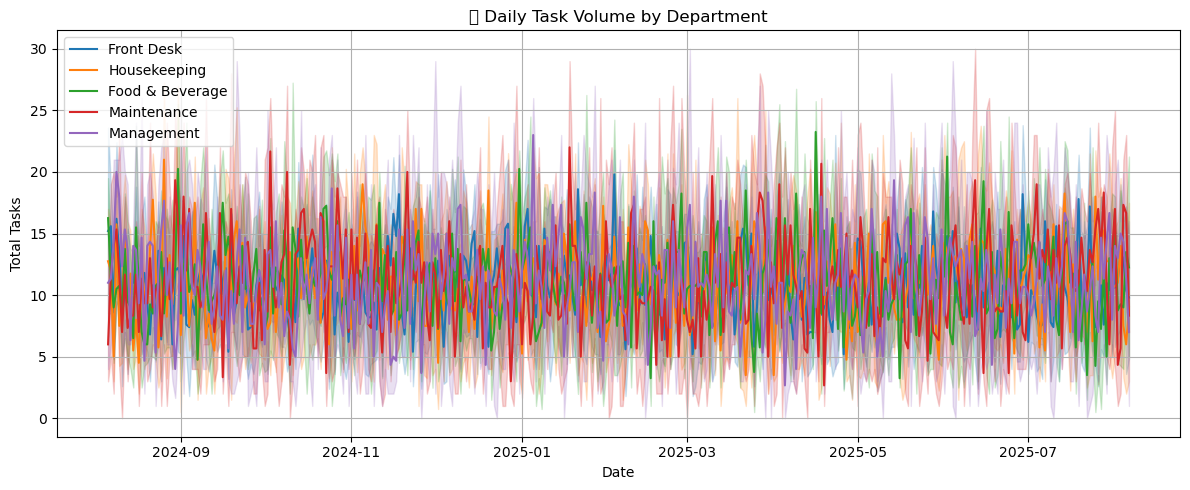

In [20]:
# load tasks and guests datasets
df_tasks = pd.read_csv('data/daily_staff_tasks.csv', parse_dates=['date'])
df_guests = pd.read_csv('data/hotel_guest_traffic.csv', parse_dates=['date'])

#change the date format
df_tasks['date'] = pd.to_datetime(df_tasks['date'])

#print shape
print("Synthetic staff task dataset shape:", df_tasks.shape)


# Plot: Daily volume of tasks by department
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_tasks, x='date', y='task_count', hue='department')
plt.title("📆 Daily Task Volume by Department")
plt.ylabel("Total Tasks")
plt.xlabel("Date")
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
# Merge both datasets on 'date'
df_merged = pd.merge(df_guests, df_tasks, on='date')
df_merged.head(10)
# df_merged.columns


,date,day_of_week,occupancy_rate,guests,event_day,department,task,task_count
0,2024-08-06,Tuesday,0.92,77,False,Front Desk,Check-ins,2
1,2024-08-06,Tuesday,0.92,77,False,Front Desk,Check-outs,6
2,2024-08-06,Tuesday,0.92,77,False,Front Desk,Phone Calls,18
3,2024-08-06,Tuesday,0.92,77,False,Front Desk,Guest Inquiries,29
4,2024-08-06,Tuesday,0.92,77,False,Front Desk,Complaints,21
5,2024-08-06,Tuesday,0.92,77,False,Housekeeping,Room Cleaning,15
6,2024-08-06,Tuesday,0.92,77,False,Housekeeping,Linen Change,19
7,2024-08-06,Tuesday,0.92,77,False,Housekeeping,Supply Restock,7
8,2024-08-06,Tuesday,0.92,77,False,Housekeeping,Maintenance Report,10
9,2024-08-06,Tuesday,0.92,77,False,Food & Beverage,Room Service Orders,14


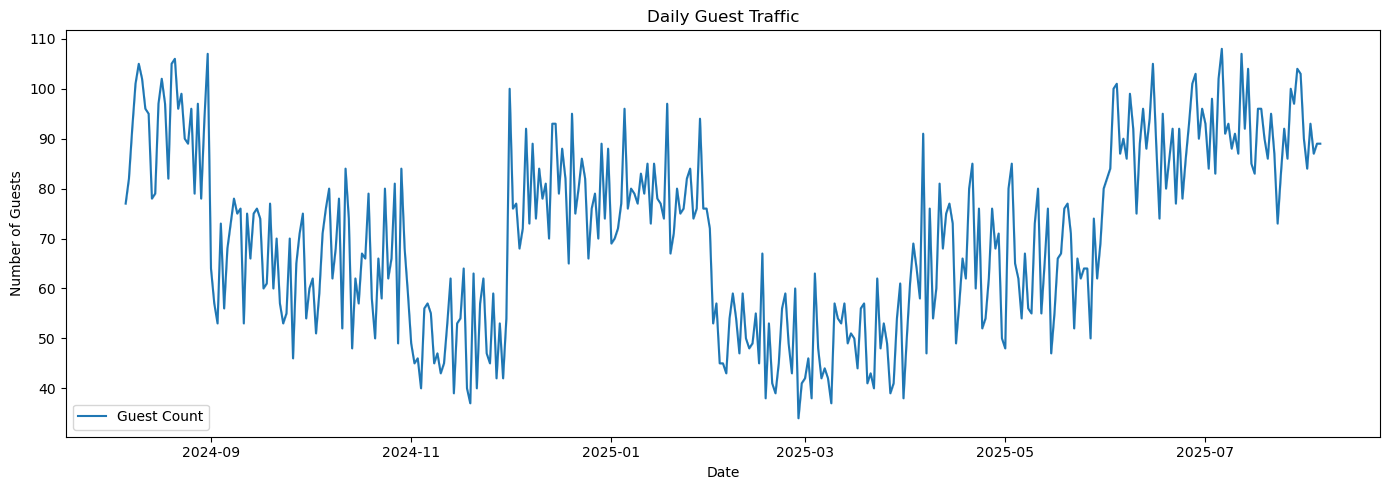

In [22]:
# Visualize guest traffic over time
plt.figure(figsize=(14, 5))
sns.lineplot(data=df_merged, x='date', y='guests', label='Guest Count')
plt.title('Daily Guest Traffic')
plt.xlabel('Date')
plt.ylabel('Number of Guests')
plt.tight_layout()
plt.show()

This graph is telling us in the past year to till now Number of guests are fluctuating, recently it is going up. may be summer events are coming soon. Before we make any decision let visulize key staff metrics over time

In [36]:
print(df_merged.columns)

# let see the unique values of tasks what are the different tasks are being operated
df_merged['task'].unique()



Index(['date', 'day_of_week', 'occupancy_rate', 'guests', 'event_day',
       'department', 'task', 'task_count'],
      dtype='object')


array(['Check-ins', 'Check-outs', 'Phone Calls', 'Guest Inquiries',
       'Complaints', 'Room Cleaning', 'Linen Change', 'Supply Restock',
       'Maintenance Report', 'Room Service Orders', 'Buffet Service',
       'Table Service', 'Inventory Check', 'Fix Requests',
       'Safety Checks', 'Equipment Maintenance', 'Staff Meetings',
       'Report Preparation', 'Customer Feedback Review'], dtype=object)

<Axes: xlabel='date', ylabel='task_count'>

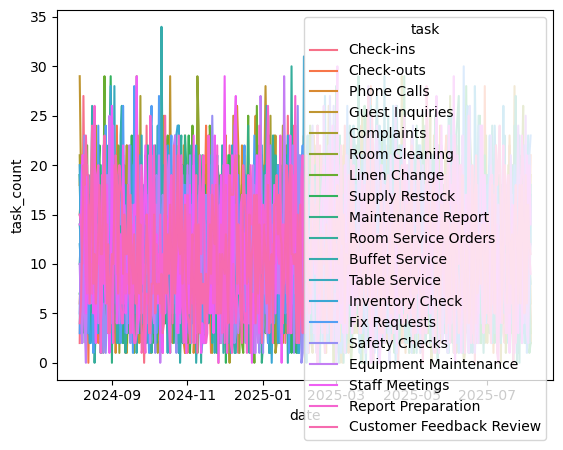

In [37]:
# visualize key staff metrics over time
sns.lineplot(data=df_merged, x='date', y='task_count', hue='task')

### This is messy graph lets focus on important task that needs to be handled at any cost

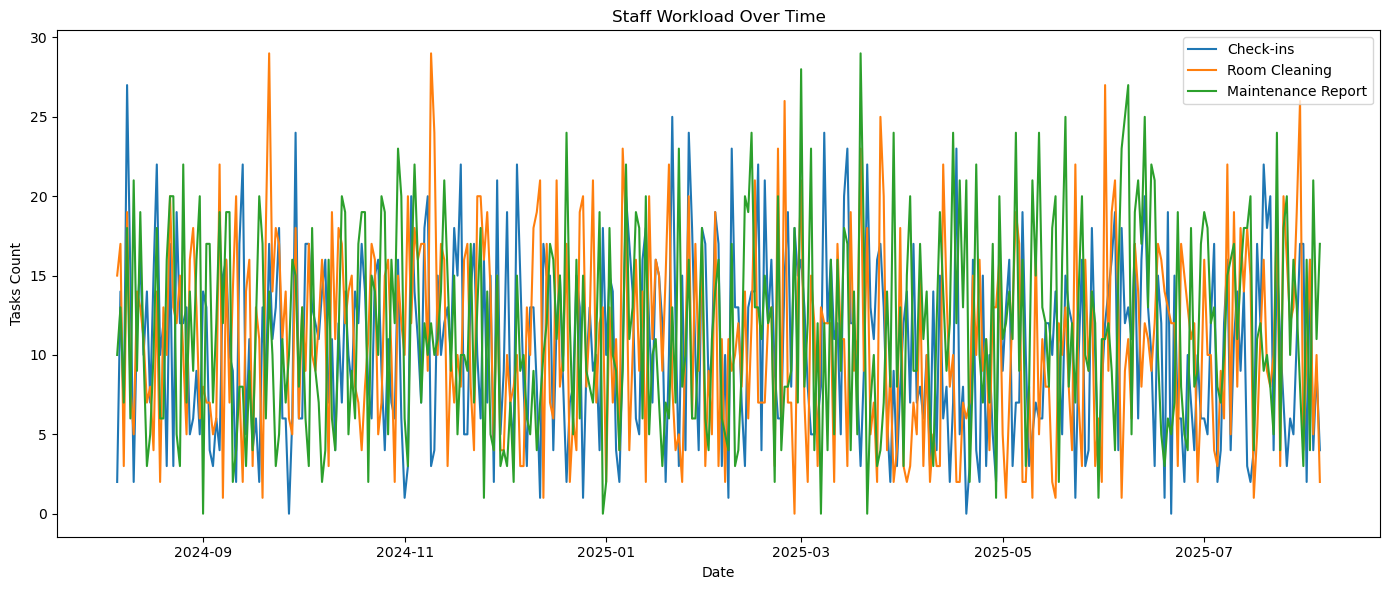

In [39]:
# select few tasks
selected_tasks = ['Check-ins','Room Cleaning', 'Maintenance Report']
# filter dataframe
df_filtered_tasks = df_merged[df_merged['task'].isin(selected_tasks)]

# plot the filtered data
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_filtered_tasks, x='date', y='task_count', hue='task')
plt.title('Staff Workload Over Time')
plt.xlabel('Date')
plt.ylabel('Tasks Count')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6935 entries, 0 to 6934
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            6935 non-null   datetime64[ns]
 1   day_of_week     6935 non-null   object        
 2   occupancy_rate  6935 non-null   float64       
 3   guests          6935 non-null   int64         
 4   event_day       6935 non-null   bool          
 5   department      6935 non-null   object        
 6   task            6935 non-null   object        
 7   task_count      6935 non-null   int64         
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 386.2+ KB


In [42]:
df_merged.isnull().sum()

date              0
day_of_week       0
occupancy_rate    0
guests            0
event_day         0
department        0
task              0
task_count        0
dtype: int64